In [1]:
import random
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

CATEGORIES = ["grocery", "food_delivery", "recharge", "bill_payment", "travel",
              "ecommerce", "entertainment"]
REGIONS = ["North", "South", "East", "West"]
METHODS = ["UPI", "Wallet", "Card", "Netbanking"]
METHOD_WEIGHTS = [0.55, 0.20, 0.15, 0.10]
AMOUNTS_INR = [49, 99, 149, 299, 499, 799, 1499, 2999, 4999]
AMOUNT_WEIGHTS = [0.18, 0.16, 0.14, 0.14, 0.12, 0.10, 0.08, 0.05, 0.03]

# --- 40 merchants ---
merchants = pd.DataFrame({
    "merchant_id": range(1, 41),
    "merchant_name": [f"Merchant_{i:03d}" for i in range(1, 41)],
    "category": [random.choice(CATEGORIES) for _ in range(40)],
    "region": [random.choice(REGIONS) for _ in range(40)],
})

# --- 350 established users, signed up 30-730 days before the window start ---
window_start = datetime(2026, 1, 1)
users = pd.DataFrame({
    "user_id": range(1, 351),
    "signup_date": [window_start - timedelta(days=random.randint(30, 730)) for _ in range(350)],
})

# --- 500 baseline transactions over a 30-day window ---
rows = []
for i in range(500):
    txn_time = window_start + timedelta(
        days=random.randint(0, 29), hours=random.randint(0, 23), minutes=random.randint(0, 59))
    status = np.random.choice(["captured", "failed", "chargeback"], p=[0.92, 0.06, 0.02])
    rows.append({
        "transaction_id": f"TXN{100000+i}",
        "user_id": random.randint(1, 350),
        "merchant_id": random.randint(1, 40),
        "transaction_time": txn_time,
        "amount_inr": np.random.choice(AMOUNTS_INR, p=AMOUNT_WEIGHTS),
        "payment_method": np.random.choice(METHODS, p=METHOD_WEIGHTS),
        "status": status,
        "risk_score": random.randint(0, 100),
    })

# --- inject 15 "burner account" chargeback frauds: brand-new users (< 30 days old) ---
next_user_id = 351
for i in range(15):
    txn_time = window_start + timedelta(days=random.randint(10, 29), hours=random.randint(0, 23))
    signup = txn_time - timedelta(days=random.randint(1, 25))
    users = pd.concat([users, pd.DataFrame([{"user_id": next_user_id, "signup_date": signup}])],
                       ignore_index=True)
    rows.append({
        "transaction_id": f"TXN{200000+i}",
        "user_id": next_user_id,
        "merchant_id": random.randint(1, 40),
        "transaction_time": txn_time,
        "amount_inr": random.choice([999, 1999, 2999, 4999]),
        "payment_method": "Card",
        "status": "chargeback",
        "risk_score": random.randint(70, 100),
    })
    next_user_id += 1

# --- inject 8 velocity-attack clusters: 4 rapid-fire txns each within a 5-minute window ---
for cluster in range(8):
    victim_user = random.randint(1, 350)
    base_time = window_start + timedelta(days=random.randint(0, 29), hours=random.randint(0, 23))
    for k in range(4):
        rows.append({
            "transaction_id": f"TXN{300000 + cluster*4 + k}",
            "user_id": victim_user,
            "merchant_id": random.randint(1, 40),
            "transaction_time": base_time + timedelta(minutes=k),
            "amount_inr": random.choice([299, 399, 499]),
            "payment_method": "Card",
            "status": "captured" if k == 3 else "failed",
            "risk_score": random.randint(60, 95),
        })

ledger = pd.DataFrame(rows)  # 500 + 15 + 32 = 547 rows
merchants.to_csv("merchants.csv", index=False)
users.to_csv("users.csv", index=False)
ledger.to_csv("ledger.csv", index=False)

# --- build the deliberately-discrepant "gateway export" copy for reconciliation ---
gateway = ledger.copy()
n = len(gateway)
missing_idx = np.random.choice(n, size=int(0.05 * n), replace=False)
gateway = gateway.drop(index=missing_idx).reset_index(drop=True)

mismatch_idx = np.random.choice(len(gateway), size=int(0.03 * n), replace=False)
gateway.loc[mismatch_idx, "amount_inr"] = gateway.loc[mismatch_idx, "amount_inr"] + \
    np.random.choice([-100, -50, 50, 100], size=len(mismatch_idx))

extra_rows = []
for i in range(int(0.02 * n)):
    extra_rows.append({
        "transaction_id": f"TXNX{9000+i}", "user_id": random.randint(1, 350),
        "merchant_id": random.randint(1, 40),
        "transaction_time": window_start + timedelta(days=random.randint(0, 29)),
        "amount_inr": random.choice(AMOUNTS_INR),
        "payment_method": random.choice(METHODS),
        "status": "captured",
        "risk_score": random.randint(0, 100),
    })
gateway = pd.concat([gateway, pd.DataFrame(extra_rows)], ignore_index=True)

status_idx = np.random.choice(len(gateway), size=int(0.02 * n), replace=False)
gateway.loc[status_idx, "status"] = "failed"

gateway.to_csv("gateway_export.csv", index=False)


In [2]:
def sql_escape(value):
    return str(value).replace("'", "''")


def dataframe_to_sql(df, table_name):
    statements = []

    for _, row in df.iterrows():

        values = []

        for value in row:

            if pd.isna(value):
                values.append("NULL")

            elif isinstance(value, (int, float, np.integer, np.floating)):
                values.append(str(value))

            else:
                values.append(
                    "'" + sql_escape(value) + "'")

        statement = (
            f"INSERT INTO {table_name} VALUES "
            f"({', '.join(values)});")

        statements.append(statement)

    return "\n".join(statements)

In [3]:
merchant_sql = dataframe_to_sql(merchants,"merchants")

print(merchant_sql[:3000])

INSERT INTO merchants VALUES (1, 'Merchant_001', 'ecommerce', 'South');
INSERT INTO merchants VALUES (2, 'Merchant_002', 'grocery', 'West');
INSERT INTO merchants VALUES (3, 'Merchant_003', 'grocery', 'East');
INSERT INTO merchants VALUES (4, 'Merchant_004', 'ecommerce', 'East');
INSERT INTO merchants VALUES (5, 'Merchant_005', 'recharge', 'South');
INSERT INTO merchants VALUES (6, 'Merchant_006', 'food_delivery', 'South');
INSERT INTO merchants VALUES (7, 'Merchant_007', 'food_delivery', 'East');
INSERT INTO merchants VALUES (8, 'Merchant_008', 'food_delivery', 'North');
INSERT INTO merchants VALUES (9, 'Merchant_009', 'ecommerce', 'North');
INSERT INTO merchants VALUES (10, 'Merchant_010', 'grocery', 'West');
INSERT INTO merchants VALUES (11, 'Merchant_011', 'ecommerce', 'North');
INSERT INTO merchants VALUES (12, 'Merchant_012', 'ecommerce', 'East');
INSERT INTO merchants VALUES (13, 'Merchant_013', 'travel', 'East');
INSERT INTO merchants VALUES (14, 'Merchant_014', 'grocery', 'Eas

In [4]:
user_sql = dataframe_to_sql(users,"users")

print(user_sql[:3000])

INSERT INTO users VALUES (1, '2024-06-04 00:00:00');
INSERT INTO users VALUES (2, '2025-03-27 00:00:00');
INSERT INTO users VALUES (3, '2025-06-18 00:00:00');
INSERT INTO users VALUES (4, '2024-08-16 00:00:00');
INSERT INTO users VALUES (5, '2024-11-09 00:00:00');
INSERT INTO users VALUES (6, '2025-03-01 00:00:00');
INSERT INTO users VALUES (7, '2024-02-16 00:00:00');
INSERT INTO users VALUES (8, '2024-05-11 00:00:00');
INSERT INTO users VALUES (9, '2025-04-22 00:00:00');
INSERT INTO users VALUES (10, '2025-01-04 00:00:00');
INSERT INTO users VALUES (11, '2025-10-06 00:00:00');
INSERT INTO users VALUES (12, '2025-04-12 00:00:00');
INSERT INTO users VALUES (13, '2025-10-31 00:00:00');
INSERT INTO users VALUES (14, '2025-01-13 00:00:00');
INSERT INTO users VALUES (15, '2024-10-18 00:00:00');
INSERT INTO users VALUES (16, '2025-03-03 00:00:00');
INSERT INTO users VALUES (17, '2025-09-26 00:00:00');
INSERT INTO users VALUES (18, '2025-04-30 00:00:00');
INSERT INTO users VALUES (19, '2024-0

In [5]:
transaction_sql = dataframe_to_sql(ledger,"transactions")

print(transaction_sql[:3000])

INSERT INTO transactions VALUES ('TXN100000', 350, 16, '2026-01-29 11:13:00', 2999, 'Wallet', 'captured', 85);
INSERT INTO transactions VALUES ('TXN100001', 287, 27, '2026-01-04 11:49:00', 49, 'UPI', 'captured', 79);
INSERT INTO transactions VALUES ('TXN100002', 122, 11, '2026-01-24 04:59:00', 1499, 'Wallet', 'captured', 22);
INSERT INTO transactions VALUES ('TXN100003', 92, 22, '2026-01-29 13:01:00', 49, 'Netbanking', 'captured', 100);
INSERT INTO transactions VALUES ('TXN100004', 343, 16, '2026-01-30 13:51:00', 99, 'UPI', 'captured', 34);
INSERT INTO transactions VALUES ('TXN100005', 196, 3, '2026-01-06 22:06:00', 99, 'UPI', 'captured', 60);
INSERT INTO transactions VALUES ('TXN100006', 236, 23, '2026-01-08 06:52:00', 99, 'Wallet', 'captured', 39);
INSERT INTO transactions VALUES ('TXN100007', 13, 13, '2026-01-27 07:14:00', 99, 'UPI', 'captured', 51);
INSERT INTO transactions VALUES ('TXN100008', 36, 18, '2026-01-11 08:55:00', 799, 'UPI', 'captured', 44);
INSERT INTO transactions VAL

In [6]:
all_insert_sql = (
    merchant_sql
    + "\n"
    + user_sql
    + "\n"
    + transaction_sql)

print(len(all_insert_sql))

81758


In [7]:
with open("paytm_data.sql", "w", encoding="utf-8") as f:
    f.write(all_insert_sql)

print("paytm_data.sql created")

paytm_data.sql created


In [8]:
import pandas as pd

ledger_df = pd.read_csv("ledger.csv")
gateway_df = pd.read_csv("gateway_export.csv")

print("Ledger shape:", ledger_df.shape)
print("Gateway shape:", gateway_df.shape)

Ledger shape: (547, 8)
Gateway shape: (530, 8)


In [9]:
ledger_df.head()

,transaction_id,user_id,merchant_id,transaction_time,amount_inr,payment_method,status,risk_score
0,TXN100000,350,16,2026-01-29 11:13:00,2999,Wallet,captured,85
1,TXN100001,287,27,2026-01-04 11:49:00,49,UPI,captured,79
2,TXN100002,122,11,2026-01-24 04:59:00,1499,Wallet,captured,22
3,TXN100003,92,22,2026-01-29 13:01:00,49,Netbanking,captured,100
4,TXN100004,343,16,2026-01-30 13:51:00,99,UPI,captured,34


In [10]:
gateway_df.head()

,transaction_id,user_id,merchant_id,transaction_time,amount_inr,payment_method,status,risk_score
0,TXN100001,287,27,2026-01-04 11:49:00,49,UPI,captured,79
1,TXN100002,122,11,2026-01-24 04:59:00,1499,Wallet,captured,22
2,TXN100003,92,22,2026-01-29 13:01:00,49,Netbanking,captured,100
3,TXN100004,343,16,2026-01-30 13:51:00,99,UPI,captured,34
4,TXN100006,236,23,2026-01-08 06:52:00,99,Wallet,captured,39


In [11]:
def reconcile_payments(ledger_df, gateway_df):

# 1. Get transaction IDs from both systems
    ledger_ids = set(ledger_df["transaction_id"])
    gateway_ids = set(gateway_df["transaction_id"])

# 2. Set operations
# Transactions present in ledger but not gateway
    missing_in_gateway_ids = ledger_ids - gateway_ids

# Transactions present in gateway but not ledger
    extra_in_gateway_ids = gateway_ids - ledger_ids

# 3. Convert the ID sets back into DataFrames
    missing_in_gateway = ledger_df[
        ledger_df["transaction_id"].isin(missing_in_gateway_ids)
    ].copy()

    extra_in_gateway = gateway_df[
        gateway_df["transaction_id"].isin(extra_in_gateway_ids)
    ].copy()

# 4. Compare transactions existing in BOTH systems
    common_transactions = pd.merge(
        ledger_df,
        gateway_df,
        on="transaction_id",
        how="inner",
        suffixes=("_ledger", "_gateway"))

# 5. Amount mismatches
    amount_mismatches = common_transactions[
        common_transactions["amount_inr_ledger"]
        != common_transactions["amount_inr_gateway"]
    ].copy()

    amount_mismatches["amount_difference"] = (
        amount_mismatches["amount_inr_gateway"]
        - amount_mismatches["amount_inr_ledger"])

# 6. Status mismatches
    status_mismatches = common_transactions[
        common_transactions["status_ledger"]
        != common_transactions["status_gateway"]
    ].copy()

# 7. Return the four required DataFrames
    return (
        missing_in_gateway,
        extra_in_gateway,
        amount_mismatches,
        status_mismatches)

In [12]:
(missing_in_gateway,
 extra_in_gateway,
 amount_mismatches,
 status_mismatches) = reconcile_payments(
    ledger_df,
    gateway_df)

In [13]:
print("RECONCILIATION RESULTS:")

print("Missing in gateway:",len(missing_in_gateway))

print("Extra in gateway:",len(extra_in_gateway))

print("Amount mismatches:",len(amount_mismatches))

print("Status mismatches:",len(status_mismatches))

RECONCILIATION RESULTS:
Missing in gateway: 27
Extra in gateway: 10
Amount mismatches: 16
Status mismatches: 9


In [14]:
missing_in_gateway.head(10)

,transaction_id,user_id,merchant_id,transaction_time,amount_inr,payment_method,status,risk_score
0,TXN100000,350,16,2026-01-29 11:13:00,2999,Wallet,captured,85
5,TXN100005,196,3,2026-01-06 22:06:00,99,UPI,captured,60
36,TXN100036,321,16,2026-01-25 16:31:00,49,UPI,captured,35
44,TXN100044,309,15,2026-01-24 23:34:00,99,Netbanking,captured,62
56,TXN100056,132,24,2026-01-07 14:44:00,299,Wallet,captured,21
74,TXN100074,244,32,2026-01-18 07:44:00,149,UPI,captured,57
92,TXN100092,157,37,2026-01-28 18:27:00,499,Wallet,captured,79
130,TXN100130,211,3,2026-01-13 07:54:00,149,UPI,chargeback,40
134,TXN100134,74,27,2026-01-17 14:00:00,799,UPI,captured,83
188,TXN100188,32,31,2026-01-15 20:01:00,299,UPI,captured,51


In [15]:
extra_in_gateway.head(10)

,transaction_id,user_id,merchant_id,transaction_time,amount_inr,payment_method,status,risk_score
520,TXNX9000,262,25,2026-01-14 00:00:00,149,Netbanking,captured,54
521,TXNX9001,96,32,2026-01-21 00:00:00,4999,Wallet,captured,71
522,TXNX9002,86,32,2026-01-10 00:00:00,149,Wallet,captured,40
523,TXNX9003,231,40,2026-01-02 00:00:00,799,UPI,captured,62
524,TXNX9004,70,13,2026-01-27 00:00:00,1499,Netbanking,captured,52
525,TXNX9005,252,27,2026-01-23 00:00:00,2999,Netbanking,captured,21
526,TXNX9006,43,37,2026-01-01 00:00:00,299,Card,captured,4
527,TXNX9007,141,15,2026-01-18 00:00:00,499,Wallet,captured,99
528,TXNX9008,235,37,2026-01-24 00:00:00,2999,UPI,captured,73
529,TXNX9009,59,18,2026-01-25 00:00:00,4999,Card,captured,69


In [16]:
amount_mismatches[
    ["transaction_id",
        "amount_inr_ledger",
        "amount_inr_gateway",
        "amount_difference"]
].head(10)

,transaction_id,amount_inr_ledger,amount_inr_gateway,amount_difference
9,TXN100011,2999,2949,-50
17,TXN100019,49,99,50
36,TXN100039,1499,1399,-100
194,TXN100204,49,-51,-100
207,TXN100218,49,-1,-50
240,TXN100252,299,349,50
257,TXN100270,799,899,100
265,TXN100278,149,99,-50
271,TXN100284,1499,1399,-100
273,TXN100286,49,149,100


In [17]:
status_mismatches[
    ["transaction_id",
        "status_ledger",
        "status_gateway"]
].head(10)

,transaction_id,status_ledger,status_gateway
39,TXN100042,captured,failed
204,TXN100215,captured,failed
254,TXN100267,captured,failed
286,TXN100300,captured,failed
371,TXN100392,captured,failed
392,TXN100414,captured,failed
463,TXN100487,captured,failed
482,TXN200008,chargeback,failed
516,TXN300027,captured,failed


In [18]:
pd.merge(
    ledger_df,
    gateway_df,
    on="transaction_id",
    how="inner")

,transaction_id,user_id_x,merchant_id_x,transaction_time_x,amount_inr_x,payment_method_x,status_x,risk_score_x,user_id_y,merchant_id_y,transaction_time_y,amount_inr_y,payment_method_y,status_y,risk_score_y
0,TXN100001,287,27,2026-01-04 11:49:00,49,UPI,captured,79,287,27,2026-01-04 11:49:00,49,UPI,captured,79
1,TXN100002,122,11,2026-01-24 04:59:00,1499,Wallet,captured,22,122,11,2026-01-24 04:59:00,1499,Wallet,captured,22
2,TXN100003,92,22,2026-01-29 13:01:00,49,Netbanking,captured,100,92,22,2026-01-29 13:01:00,49,Netbanking,captured,100
3,TXN100004,343,16,2026-01-30 13:51:00,99,UPI,captured,34,343,16,2026-01-30 13:51:00,99,UPI,captured,34
4,TXN100006,236,23,2026-01-08 06:52:00,99,Wallet,captured,39,236,23,2026-01-08 06:52:00,99,Wallet,captured,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,TXN300026,59,38,2026-01-09 21:02:00,299,Card,failed,82,59,38,2026-01-09 21:02:00,299,Card,failed,82
516,TXN300027,59,23,2026-01-09 21:03:00,399,Card,captured,71,59,23,2026-01-09 21:03:00,399,Card,failed,71
517,TXN300028,345,40,2026-01-23 09:00:00,499,Card,failed,65,345,40,2026-01-23 09:00:00,499,Card,failed,65
518,TXN300029,345,9,2026-01-23 09:01:00,399,Card,failed,67,345,9,2026-01-23 09:01:00,399,Card,failed,67


In [19]:
print("Ledger transactions:", len(ledger_df))

print("Missing in gateway:",len(missing_in_gateway))

print("Extra in gateway:",len(extra_in_gateway))

print("Common transactions:",
    len(set(ledger_df["transaction_id"])
        & set(gateway_df["transaction_id"])))

Ledger transactions: 547
Missing in gateway: 27
Extra in gateway: 10
Common transactions: 520


In [20]:
missing_in_gateway.to_csv("missing_in_gateway.csv",index=False)

extra_in_gateway.to_csv("extra_in_gateway.csv", index=False)

amount_mismatches.to_csv("amount_mismatches.csv",index=False)

status_mismatches.to_csv("status_mismatches.csv",index=False)

print("Four reconciliation reports saved.")

Four reconciliation reports saved.


In [21]:
reconciliation_summary = pd.DataFrame({
    "discrepancy_type": [
        "Missing in gateway",
        "Extra in gateway",
        "Amount mismatch",
        "Status mismatch"    ],
    "count": [
        len(missing_in_gateway),
        len(extra_in_gateway),
        len(amount_mismatches),
        len(status_mismatches)]})

reconciliation_summary

,discrepancy_type,count
0,Missing in gateway,27
1,Extra in gateway,10
2,Amount mismatch,16
3,Status mismatch,9


In [22]:
reconciliation_summary["percentage_of_ledger"] = (
    reconciliation_summary["count"]
    / len(ledger_df)
    * 100)

reconciliation_summary

,discrepancy_type,count,percentage_of_ledger
0,Missing in gateway,27,4.936015
1,Extra in gateway,10,1.828154
2,Amount mismatch,16,2.925046
3,Status mismatch,9,1.645338


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ledger_df = pd.read_csv("ledger.csv")
gateway_df = pd.read_csv("gateway_export.csv")
merchants_df = pd.read_csv("merchants.csv")

ledger_df["transaction_time"] = pd.to_datetime(
    ledger_df["transaction_time"])

gateway_df["transaction_time"] = pd.to_datetime(
    gateway_df["transaction_time"])

print("Ledger:", ledger_df.shape)
print("Gateway:", gateway_df.shape)
print("Merchants:", merchants_df.shape)

Ledger: (547, 8)
Gateway: (530, 8)
Merchants: (40, 4)


In [24]:
dashboard_df = ledger_df.merge(
    merchants_df,
    on="merchant_id",
    how="left")

dashboard_df.head()

,transaction_id,user_id,merchant_id,transaction_time,amount_inr,payment_method,status,risk_score,merchant_name,category,region
0,TXN100000,350,16,2026-01-29 11:13:00,2999,Wallet,captured,85,Merchant_016,bill_payment,West
1,TXN100001,287,27,2026-01-04 11:49:00,49,UPI,captured,79,Merchant_027,ecommerce,North
2,TXN100002,122,11,2026-01-24 04:59:00,1499,Wallet,captured,22,Merchant_011,ecommerce,North
3,TXN100003,92,22,2026-01-29 13:01:00,49,Netbanking,captured,100,Merchant_022,travel,South
4,TXN100004,343,16,2026-01-30 13:51:00,99,UPI,captured,34,Merchant_016,bill_payment,West


In [25]:
import os

os.makedirs("dashboard", exist_ok=True)

print("Dashboard folder created.")

Dashboard folder created.


In [26]:
total_gmv = ledger_df["amount_inr"].sum()

print("Total GMV: ₹", total_gmv)

Total GMV: ₹ 382603


In [27]:
success_rate = (
    (ledger_df["status"] == "captured").sum()
    / len(ledger_df)
    * 100)

print("Success rate:", round(success_rate, 2), "%")

Success rate: 85.56 %


In [28]:
success_rate = (
    (ledger_df["status"] == "captured").sum()
    / len(ledger_df)
    * 100)

print("Success rate:", round(success_rate, 2), "%")

Success rate: 85.56 %


In [29]:
comparison = pd.merge(
    ledger_df[
        ["transaction_id", "amount_inr", "status"]],
    gateway_df[
        ["transaction_id", "amount_inr", "status"]],
    on="transaction_id",
    how="inner",
    suffixes=("_ledger", "_gateway"))

matched_count = (
    (comparison["amount_inr_ledger"]
     == comparison["amount_inr_gateway"])
    &
    (comparison["status_ledger"]
     == comparison["status_gateway"])
).sum()

match_rate = (
    matched_count
    / len(ledger_df)
    * 100)

print("Matched transactions:", matched_count)
print("Match rate:", round(match_rate, 2), "%")

Matched transactions: 495
Match rate: 90.49 %


In [30]:
comparison = pd.merge(
    ledger_df[
        ["transaction_id", "amount_inr", "status"]],
    gateway_df[
        ["transaction_id", "amount_inr", "status"]],
    on="transaction_id",
    how="inner",
    suffixes=("_ledger", "_gateway"))

matched_count = (
    (comparison["amount_inr_ledger"]
     == comparison["amount_inr_gateway"])
    &
    (comparison["status_ledger"]
     == comparison["status_gateway"])
).sum()

match_rate = (
    matched_count
    / len(ledger_df)
    * 100)

print("Matched transactions:", matched_count)
print("Match rate:", round(match_rate, 2), "%")

Matched transactions: 495
Match rate: 90.49 %


In [31]:
chargeback_count = (
    ledger_df["status"] == "chargeback"
).sum()

chargeback_ratio = (
    chargeback_count
    / len(ledger_df)
    * 100)

print("Chargeback transactions:", chargeback_count)
print("Chargeback ratio:", round(chargeback_ratio, 2), "%")

Chargeback transactions: 28
Chargeback ratio: 5.12 %


In [32]:
print("HEADLINE METRICS")
print(f"Total GMV: ₹{total_gmv:,.2f}")
print(f"Success Rate: {success_rate:.2f}%")
print(f"Reconciliation Match Rate: {match_rate:.2f}%")
print(f"Chargeback Ratio: {chargeback_ratio:.2f}%")

HEADLINE METRICS
Total GMV: ₹382,603.00
Success Rate: 85.56%
Reconciliation Match Rate: 90.49%
Chargeback Ratio: 5.12%


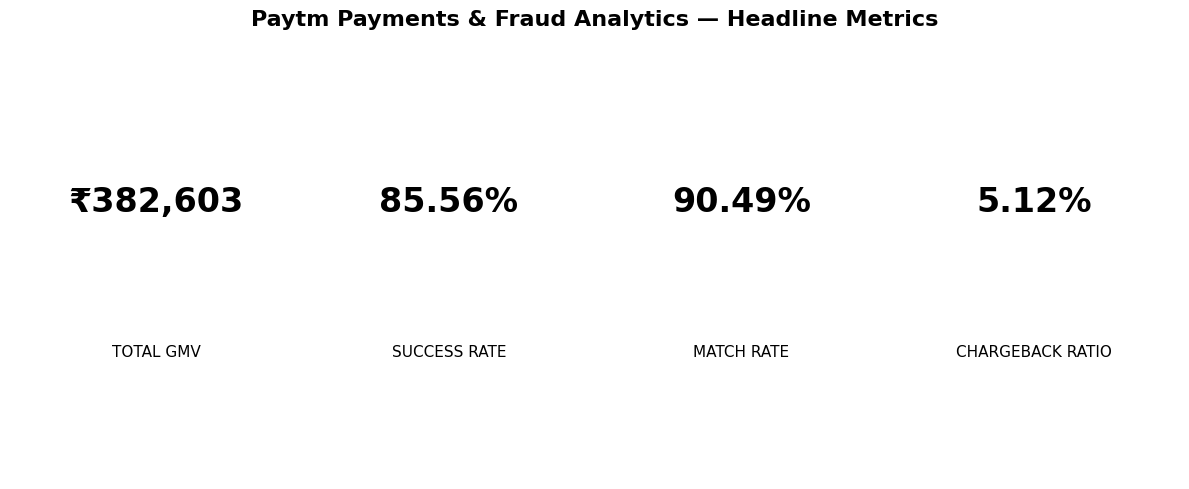

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.axis("off")

metrics = [
    ("TOTAL GMV", f"₹{total_gmv:,.0f}"),
    ("SUCCESS RATE", f"{success_rate:.2f}%"),
    ("MATCH RATE", f"{match_rate:.2f}%"),
    ("CHARGEBACK RATIO", f"{chargeback_ratio:.2f}%")]

for i, (label, value) in enumerate(metrics):
    x = (i + 0.5) / len(metrics)

    ax.text(
        x,
        0.65,
        value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        transform=ax.transAxes)

    ax.text(
        x,
        0.30,
        label,
        ha="center",
        va="center",
        fontsize=11,
        transform=ax.transAxes)

ax.set_title(
    "Paytm Payments & Fraud Analytics — Headline Metrics",
    fontsize=16,
    fontweight="bold",
    pad=20)

plt.tight_layout()

plt.savefig(
    "dashboard/01_headline.png",
    dpi=200,
    bbox_inches="tight")

plt.show()

### Headline Interpretation

The platform processed ₹382,603 in GMV with an 85.56% transaction success rate. The 90.49% reconciliation match rate shows that most transactions agree between the ledger and gateway, while the 5.12% chargeback ratio indicates a fraud signal that should be monitored.

In [34]:
ledger_df["transaction_date"] = (
    ledger_df["transaction_time"].dt.date)

daily_gmv = (
    ledger_df
    .groupby("transaction_date")["amount_inr"]
    .sum())

daily_chargebacks = (
    ledger_df[
        ledger_df["status"] == "chargeback"
    ]
    .groupby("transaction_date")
    .size())

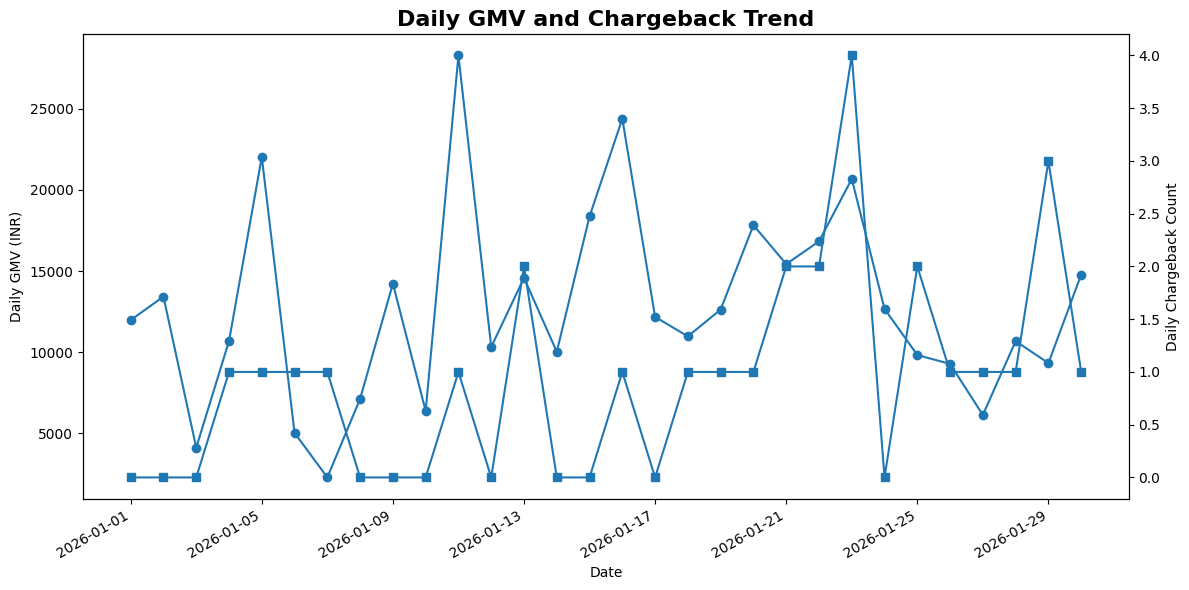

In [35]:
trend_df = pd.DataFrame({
    "daily_gmv": daily_gmv,
    "daily_chargebacks": daily_chargebacks
}).fillna(0)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    trend_df.index,
    trend_df["daily_gmv"],
    marker="o",
    label="Daily GMV")

ax1.set_xlabel("Date")
ax1.set_ylabel("Daily GMV (INR)")

ax2 = ax1.twinx()

ax2.plot(
    trend_df.index,
    trend_df["daily_chargebacks"],
    marker="s",
    label="Daily Chargebacks")

ax2.set_ylabel("Daily Chargeback Count")

ax1.set_title(
    "Daily GMV and Chargeback Trend",
    fontsize=16,
    fontweight="bold")

fig.autofmt_xdate()

plt.tight_layout()

plt.savefig(
    "dashboard/02_trends.png",
    dpi=200,
    bbox_inches="tight")

plt.show()

### Trends Interpretation

Daily GMV fluctuates across the 30-day period without a clear weekly pattern. Some higher-volume days also show increases in chargeback activity, suggesting that transaction volume and fraud exposure should be monitored together.

In [36]:
gmv_by_method = (
    dashboard_df
    .groupby("payment_method")["amount_inr"]
    .sum()
    .sort_values(ascending=False))

gmv_by_method

,amount_inr
payment_method,
UPI,172274
Card,102429
Wallet,71304
Netbanking,36596


In [37]:
gmv_by_category = (
    dashboard_df
    .groupby("category")["amount_inr"]
    .sum()
    .sort_values(ascending=False))

gmv_by_category

,amount_inr
category,
ecommerce,79896
travel,75250
grocery,71936
food_delivery,57205
entertainment,56887
bill_payment,26304
recharge,15125


In [38]:
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(gmv_by_method))
width = 0.35

method_values = gmv_by_method.values

category_values = np.array([
        gmv_by_category.get(category, 0)
        for category in gmv_by_category.index])

# We'll use two separate panels vertically in the final image
plt.close()

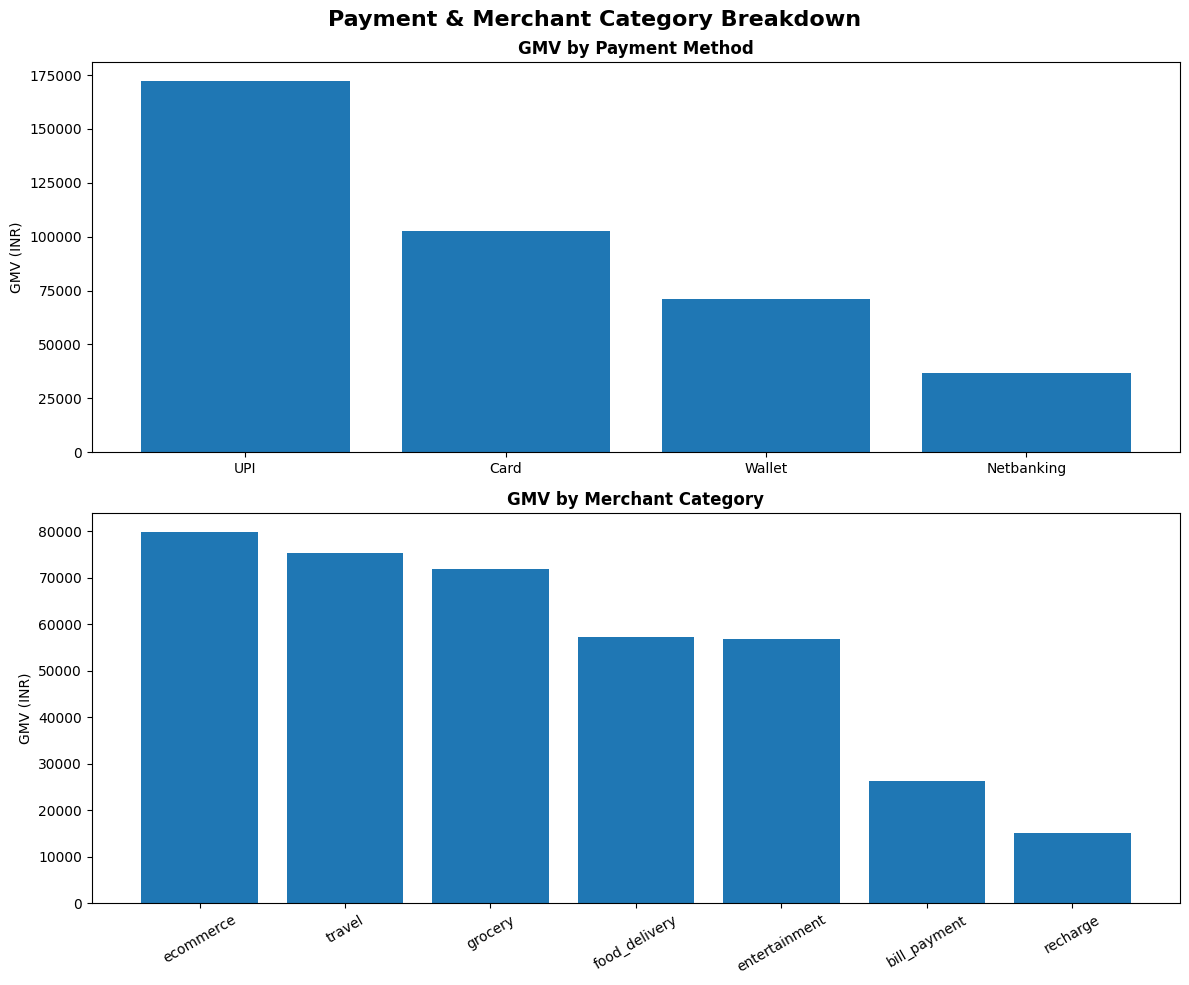

In [39]:
fig, axes = plt.subplots(2,1,
    figsize=(12, 10))

# Payment method
axes[0].bar(
    gmv_by_method.index,
    gmv_by_method.values)

axes[0].set_title(
    "GMV by Payment Method",
    fontweight="bold")

axes[0].set_ylabel("GMV (INR)")


# Category
axes[1].bar(
    gmv_by_category.index,
    gmv_by_category.values)

axes[1].set_title(
    "GMV by Merchant Category",
    fontweight="bold")

axes[1].set_ylabel("GMV (INR)")

axes[1].tick_params(axis="x", rotation=30)

fig.suptitle(
    "Payment & Merchant Category Breakdown",
    fontsize=16,
    fontweight="bold")

plt.tight_layout()

plt.savefig(
    "dashboard/03_breakdown.png",
    dpi=200,
    bbox_inches="tight")

plt.show()

### Breakdown Interpretation

UPI contributes the largest share of GMV among the payment methods, consistent with its higher transaction-generation weight in the synthetic dataset. The category breakdown shows how transaction value is distributed across the different merchant categories.

In [40]:
merchant_stats = (
    dashboard_df
    .groupby([
            "merchant_id",
            "merchant_name"])
    .agg(
        transaction_count=(
            "transaction_id",
            "count"),
        chargeback_count=(
            "status",
            lambda x: (x == "chargeback").sum()),
        total_gmv=(
            "amount_inr",
            "sum"))
    .reset_index())

In [41]:
merchant_stats["chargeback_ratio"] = (
    merchant_stats["chargeback_count"]
    / merchant_stats["transaction_count"]
    * 100)

In [42]:
merchant_stats["risk_flag"] = np.where(
    merchant_stats["chargeback_ratio"] > 1,
    "HIGH RISK",
    "Normal")

In [43]:
top10_merchants = (
    merchant_stats
    .sort_values(
        "transaction_count",
        ascending=False)
    .head(10)
    .copy())

top10_merchants

,merchant_id,merchant_name,transaction_count,chargeback_count,total_gmv,chargeback_ratio,risk_flag
15,16,Merchant_016,20,0,11130,0.000000,Normal
28,29,Merchant_029,19,3,13081,15.789474,HIGH RISK
36,37,Merchant_037,19,1,12931,5.263158,HIGH RISK
8,9,Merchant_009,18,0,4982,0.000000,Normal
2,3,Merchant_003,17,1,8233,5.882353,HIGH RISK
24,25,Merchant_025,17,1,15533,5.882353,HIGH RISK
29,30,Merchant_030,17,0,7883,0.000000,Normal
7,8,Merchant_008,16,1,7434,6.250000,HIGH RISK
35,36,Merchant_036,16,1,12534,6.250000,HIGH RISK
26,27,Merchant_027,16,3,13584,18.750000,HIGH RISK


In [44]:
top10_merchants[[
        "merchant_id",
        "merchant_name",
        "transaction_count",
        "chargeback_count",
        "chargeback_ratio",
        "risk_flag"]]

,merchant_id,merchant_name,transaction_count,chargeback_count,chargeback_ratio,risk_flag
15,16,Merchant_016,20,0,0.000000,Normal
28,29,Merchant_029,19,3,15.789474,HIGH RISK
36,37,Merchant_037,19,1,5.263158,HIGH RISK
8,9,Merchant_009,18,0,0.000000,Normal
2,3,Merchant_003,17,1,5.882353,HIGH RISK
24,25,Merchant_025,17,1,5.882353,HIGH RISK
29,30,Merchant_030,17,0,0.000000,Normal
7,8,Merchant_008,16,1,6.250000,HIGH RISK
35,36,Merchant_036,16,1,6.250000,HIGH RISK
26,27,Merchant_027,16,3,18.750000,HIGH RISK


In [45]:
display_df = top10_merchants[[
        "merchant_id",
        "merchant_name",
        "transaction_count",
        "chargeback_count",
        "chargeback_ratio",
        "risk_flag"]
].copy()

display_df["chargeback_ratio"] = (
    display_df["chargeback_ratio"]
    .round(2)
    .astype(str)
    + "%")

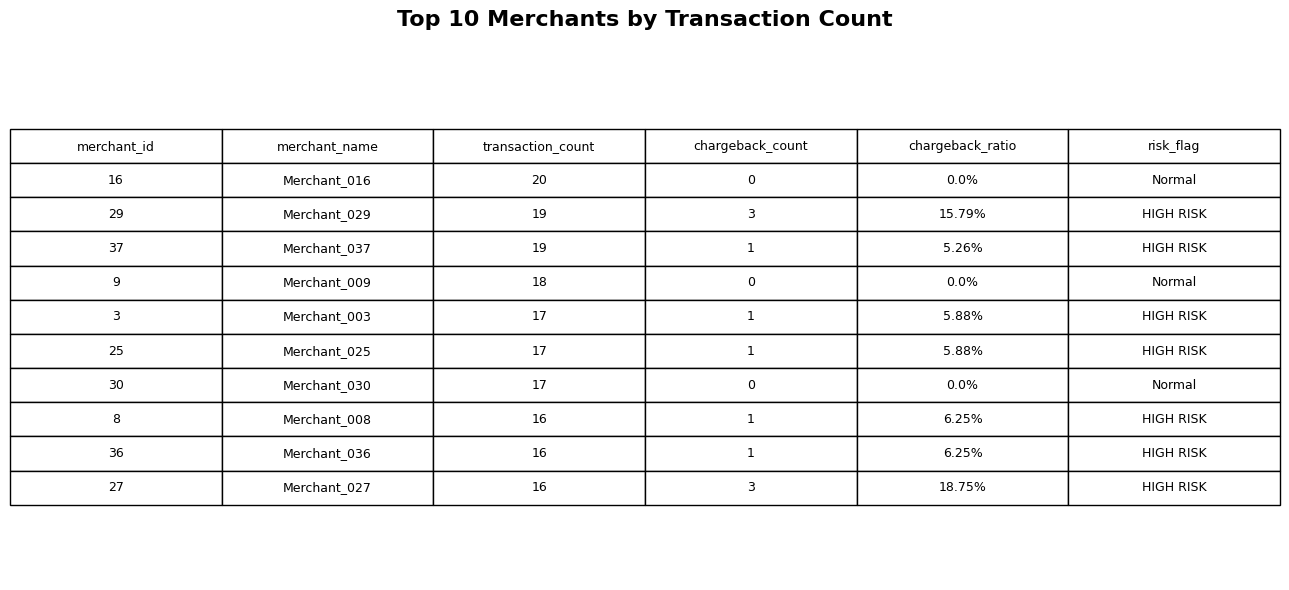

In [46]:
fig, ax = plt.subplots(
    figsize=(13, 6))

ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center")

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

ax.set_title(
    "Top 10 Merchants by Transaction Count",
    fontsize=16,
    fontweight="bold",
    pad=20)

plt.tight_layout()

plt.savefig(
    "dashboard/04_details.png",
    dpi=200,
    bbox_inches="tight")

plt.show()

### Details Interpretation

Several of the highest-volume merchants exceed the 1% chargeback-ratio threshold and therefore require closer monitoring. Merchants with particularly high chargeback ratios should be prioritized for manual review even when their overall transaction volume is relatively high.

In [47]:
print(top10_merchants[[
            "merchant_name",
            "chargeback_ratio",
            "risk_flag"]])

   merchant_name  chargeback_ratio  risk_flag
15  Merchant_016          0.000000     Normal
28  Merchant_029         15.789474  HIGH RISK
36  Merchant_037          5.263158  HIGH RISK
8   Merchant_009          0.000000     Normal
2   Merchant_003          5.882353  HIGH RISK
24  Merchant_025          5.882353  HIGH RISK
29  Merchant_030          0.000000     Normal
7   Merchant_008          6.250000  HIGH RISK
35  Merchant_036          6.250000  HIGH RISK
26  Merchant_027         18.750000  HIGH RISK


In [48]:
import sqlite3

# Create/connect to the SQLite database
conn = sqlite3.connect("paytm_payments.db")
cursor = conn.cursor()

# Enable foreign key constraints
cursor.execute("PRAGMA foreign_keys = ON;")

# Create the three tables
cursor.executescript("""
CREATE TABLE IF NOT EXISTS merchants (
    merchant_id INTEGER PRIMARY KEY,
    merchant_name TEXT,
    category TEXT,
    region TEXT
);

CREATE TABLE IF NOT EXISTS users (
    user_id INTEGER PRIMARY KEY,
    signup_date TEXT
);

CREATE TABLE IF NOT EXISTS transactions (
    transaction_id TEXT PRIMARY KEY,
    user_id INTEGER,
    merchant_id INTEGER,
    transaction_time TEXT,
    amount_inr REAL,
    payment_method TEXT,
    status TEXT,
    risk_score INTEGER,
    FOREIGN KEY (user_id) REFERENCES users(user_id),
    FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id)
);
""")

print("Database and tables created successfully.")

Database and tables created successfully.


In [49]:
import pandas as pd

# Load the CSV files
merchants_df = pd.read_csv("merchants.csv")
users_df = pd.read_csv("users.csv")
transactions_df = pd.read_csv("ledger.csv")

# Insert the data into the SQLite tables
merchants_df.to_sql("merchants", conn, if_exists="append", index=False)
users_df.to_sql("users", conn, if_exists="append", index=False)
transactions_df.to_sql("transactions", conn, if_exists="append", index=False)

print("All CSV data loaded into the database successfully.")

All CSV data loaded into the database successfully.


In [50]:
# Check the number of rows in each table

print("Merchants:", pd.read_sql("SELECT COUNT(*) AS count FROM merchants", conn)["count"][0])
print("Users:", pd.read_sql("SELECT COUNT(*) AS count FROM users", conn)["count"][0])
print("Transactions:", pd.read_sql("SELECT COUNT(*) AS count FROM transactions", conn)["count"][0])

Merchants: 40
Users: 365
Transactions: 547


In [51]:
# Query 1: Basic SELECT + LIMIT

query1 = """
SELECT *
FROM transactions
LIMIT 10;
"""

result1 = pd.read_sql_query(query1, conn)
result1

,transaction_id,user_id,merchant_id,transaction_time,amount_inr,payment_method,status,risk_score
0,TXN100000,350,16,2026-01-29 11:13:00,2999.0,Wallet,captured,85
1,TXN100001,287,27,2026-01-04 11:49:00,49.0,UPI,captured,79
2,TXN100002,122,11,2026-01-24 04:59:00,1499.0,Wallet,captured,22
3,TXN100003,92,22,2026-01-29 13:01:00,49.0,Netbanking,captured,100
4,TXN100004,343,16,2026-01-30 13:51:00,99.0,UPI,captured,34
5,TXN100005,196,3,2026-01-06 22:06:00,99.0,UPI,captured,60
6,TXN100006,236,23,2026-01-08 06:52:00,99.0,Wallet,captured,39
7,TXN100007,13,13,2026-01-27 07:14:00,99.0,UPI,captured,51
8,TXN100008,36,18,2026-01-11 08:55:00,799.0,UPI,captured,44
9,TXN100009,348,35,2026-01-21 16:25:00,299.0,UPI,captured,42


In [52]:
query = """
SELECT
    transaction_id,
    user_id,
    amount_inr,
    status
FROM transactions
WHERE status = 'chargeback'
ORDER BY amount_inr DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,transaction_id,user_id,amount_inr,status
0,TXN100177,328,4999.0,chargeback
1,TXN200001,352,4999.0,chargeback
2,TXN200003,354,4999.0,chargeback
3,TXN200004,355,4999.0,chargeback
4,TXN200010,361,4999.0,chargeback
5,TXN200011,362,4999.0,chargeback
6,TXN100337,226,2999.0,chargeback
7,TXN200005,356,2999.0,chargeback
8,TXN200008,359,2999.0,chargeback
9,TXN200000,351,1999.0,chargeback


In [53]:
query_payment_method = """
SELECT DISTINCT payment_method
FROM transactions;
"""

pd.read_sql_query(query_payment_method, conn)

,payment_method
0,Wallet
1,UPI
2,Netbanking
3,Card


In [54]:
query_merchant_counts = """
SELECT
    merchant_id,
    COUNT(*) AS transaction_count
FROM transactions
GROUP BY merchant_id
HAVING COUNT(*) > 10
ORDER BY transaction_count DESC;
"""

result_merchant_counts = pd.read_sql_query(query_merchant_counts, conn)
result_merchant_counts

,merchant_id,transaction_count
0,16,20
1,37,19
2,29,19
3,9,18
4,30,17
5,25,17
6,3,17
7,36,16
8,34,16
9,27,16


In [55]:
query_chargeback_summary = """
SELECT
    COUNT(*) AS chargeback_count,
    COUNT(DISTINCT user_id) AS unique_users_affected,
    SUM(amount_inr) AS total_chargeback_amount
FROM transactions
WHERE status = 'chargeback';
"""

chargeback_summary = pd.read_sql_query(query_chargeback_summary, conn)
chargeback_summary

,chargeback_count,unique_users_affected,total_chargeback_amount
0,28,27,54472.0


In [56]:
query_transactions_users = """
SELECT
    t.transaction_id,
    t.user_id,
    u.signup_date,
    t.amount_inr,
    t.status
FROM transactions t
INNER JOIN users u
    ON t.user_id = u.user_id
LIMIT 10;
"""

result_transactions_users = pd.read_sql_query(query_transactions_users, conn)
result_transactions_users

,transaction_id,user_id,signup_date,amount_inr,status
0,TXN100000,350,2025-10-23 00:00:00,2999.0,captured
1,TXN100001,287,2024-11-19 00:00:00,49.0,captured
2,TXN100002,122,2024-01-15 00:00:00,1499.0,captured
3,TXN100003,92,2025-01-05 00:00:00,49.0,captured
4,TXN100004,343,2024-05-16 00:00:00,99.0,captured
5,TXN100005,196,2024-02-04 00:00:00,99.0,captured
6,TXN100006,236,2024-06-30 00:00:00,99.0,captured
7,TXN100007,13,2025-10-31 00:00:00,99.0,captured
8,TXN100008,36,2024-04-14 00:00:00,799.0,captured
9,TXN100009,348,2025-01-21 00:00:00,299.0,captured


In [57]:
query_transactions_merchants = """
SELECT
    t.transaction_id,
    t.merchant_id,
    m.merchant_name,
    m.category,
    m.region
FROM transactions t
LEFT JOIN merchants m
    ON t.merchant_id = m.merchant_id
LIMIT 10;
"""

result_transactions_merchants = pd.read_sql_query(query_transactions_merchants, conn)
result_transactions_merchants

,transaction_id,merchant_id,merchant_name,category,region
0,TXN100000,16,Merchant_016,bill_payment,West
1,TXN100001,27,Merchant_027,ecommerce,North
2,TXN100002,11,Merchant_011,ecommerce,North
3,TXN100003,22,Merchant_022,travel,South
4,TXN100004,16,Merchant_016,bill_payment,West
5,TXN100005,3,Merchant_003,grocery,East
6,TXN100006,23,Merchant_023,travel,North
7,TXN100007,13,Merchant_013,travel,East
8,TXN100008,18,Merchant_018,grocery,West
9,TXN100009,35,Merchant_035,recharge,East


In [58]:
query_fraud_early_transactions = """
SELECT
    t.transaction_id,
    t.user_id,
    u.signup_date,
    t.transaction_time,
    t.amount_inr,
    t.status,
    ROUND(
        julianday(t.transaction_time)
        - julianday(u.signup_date),
        2
    ) AS account_age_days
FROM transactions t
INNER JOIN users u
    ON t.user_id = u.user_id
WHERE t.status = 'chargeback'
  AND julianday(t.transaction_time) >= julianday(u.signup_date)
  AND julianday(t.transaction_time)
      - julianday(u.signup_date) < 30
ORDER BY account_age_days;
"""

result_fraud_early_transactions = pd.read_sql_query(query_fraud_early_transactions, conn)
result_fraud_early_transactions

,transaction_id,user_id,signup_date,transaction_time,amount_inr,status,account_age_days
0,TXN200006,357,2026-01-19 11:00:00,2026-01-23 11:00:00,1999.0,chargeback,4.0
1,TXN200008,359,2026-01-18 22:00:00,2026-01-25 22:00:00,2999.0,chargeback,7.0
2,TXN200010,361,2026-01-11 07:00:00,2026-01-20 07:00:00,4999.0,chargeback,9.0
3,TXN200001,352,2025-12-31 12:00:00,2026-01-11 12:00:00,4999.0,chargeback,11.0
4,TXN200002,353,2026-01-10 14:00:00,2026-01-21 14:00:00,1999.0,chargeback,11.0
5,TXN200004,355,2026-01-05 12:00:00,2026-01-16 12:00:00,4999.0,chargeback,11.0
6,TXN200005,356,2026-01-18 07:00:00,2026-01-29 07:00:00,2999.0,chargeback,11.0
7,TXN200000,351,2026-01-15 06:00:00,2026-01-30 06:00:00,1999.0,chargeback,15.0
8,TXN200011,362,2026-01-08 02:00:00,2026-01-23 02:00:00,4999.0,chargeback,15.0
9,TXN200012,363,2026-01-06 17:00:00,2026-01-23 17:00:00,999.0,chargeback,17.0


In [59]:
query_ten_minute_bucket = """
SELECT
    user_id,
    datetime(
        (CAST(strftime('%s', transaction_time) AS INTEGER) / 600) * 600,
        'unixepoch'
    ) AS ten_minute_bucket,
    COUNT(*) AS transaction_count
FROM transactions
GROUP BY
    user_id,
    ten_minute_bucket
HAVING COUNT(*) >= 3
ORDER BY transaction_count DESC;
"""

result_ten_minute_bucket = pd.read_sql_query(query_ten_minute_bucket, conn)
result_ten_minute_bucket

,user_id,ten_minute_bucket,transaction_count
0,59,2026-01-09 21:00:00,4
1,73,2026-01-12 09:00:00,4
2,154,2026-01-02 22:00:00,4
3,200,2026-01-01 22:00:00,4
4,229,2026-01-12 12:00:00,4
5,287,2026-01-14 14:00:00,4
6,314,2026-01-02 18:00:00,4
7,345,2026-01-23 09:00:00,4
